#Gráficos de projetos aprovados por deputado

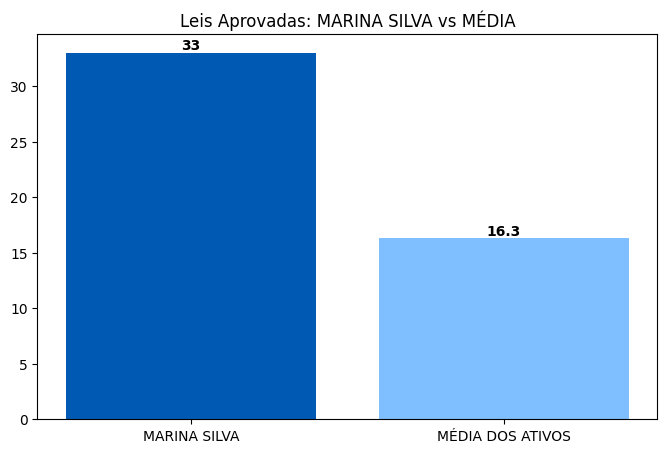

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

caminho_ranking = 'https://raw.githubusercontent.com/APILumina/API1_DSM_Lumina/refs/heads/feature/codigos-graficos/data/deputados/tratado/ranking_projetos_filtrado.csv'
df_ranking = pd.read_csv(caminho_ranking, sep=';')

df_ranking['nome_busca'] = df_ranking['nome'].str.strip().str.lower()

media_aprovados = df_ranking['qtd'].mean()

def gerar_grafico_para_site(nome_escolhido):
    nome_busca = nome_escolhido.strip().lower()

    dados_deputado = df_ranking[df_ranking['nome_busca'] == nome_busca]

    #Se o deputado não for encontrado ou não tiver projeto aprovado
    if dados_deputado.empty:
        print(f"Deputado '{nome_escolhido}' não encontrado ou sem projetos aprovados.")
        return

    total_deputado = dados_deputado['qtd'].values[0]
    nome_exibicao = dados_deputado['nome'].values[0]

    #Parte estética do gráfico
    plt.figure(figsize=(8, 5))
    plt.bar([nome_exibicao, 'MÉDIA DOS ATIVOS'], [total_deputado, media_aprovados], color=['#0059b3', '#80bfff'])

    #Valores do topo da barra
    plt.text(0, total_deputado, f'{total_deputado}', ha='center', va='bottom', fontweight='bold')
    plt.text(1, media_aprovados, f'{media_aprovados:.1f}', ha='center', va='bottom', fontweight='bold')

    plt.title(f'Leis Aprovadas: {nome_exibicao} vs MÉDIA')
    plt.show()

#Exemplo
gerar_grafico_para_site('Marina Silva')

O gráfico gerado mostra uma comparação entre o número de projetos da deputada Marina Silva e a média de projetos de todos os deputados ativos com projetos aprovados na Câmara.